In [1]:
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [2]:
import pandas as pd

import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

ModuleNotFoundError: No module named 'pandas'

In [7]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

train_df.head()

Train Shape : (7613, 5)
Test Shape : (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [8]:
print(train_df.info())

print("\nMissing Values\n")
print(train_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB
None

Missing Values

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


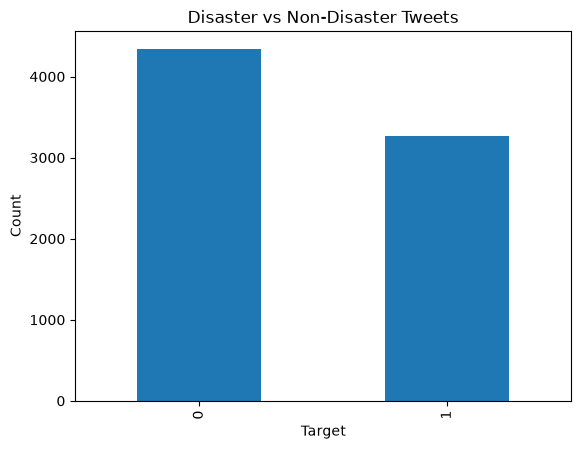

In [9]:
train_df["target"].value_counts().plot(
    kind="bar",
    title="Disaster vs Non-Disaster Tweets"
)

plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

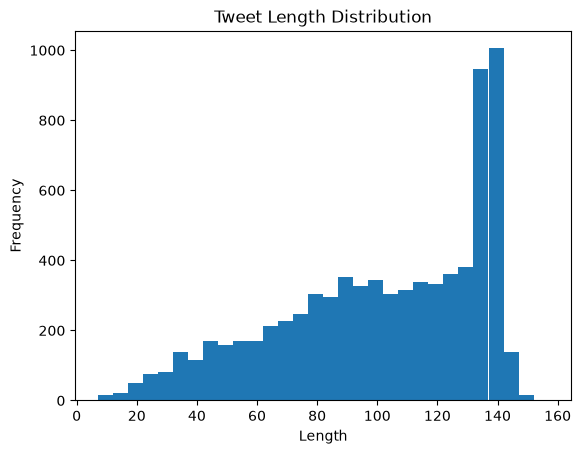

In [10]:
train_df["tweet_length"] = train_df["text"].apply(len)

plt.hist(train_df["tweet_length"], bins=30)

plt.title("Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

In [11]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
train_df["clean_text"] = train_df["text"].apply(clean_text)

test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df.head()

,id,keyword,location,text,target,tweet_length,clean_text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,our deeds are the reason of this earthquake ma...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,forest fire near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,all residents asked to shelter in place are be...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,13000 people receive wildfires evacuation orde...
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,just got sent this photo from ruby alaska as s...


In [13]:
X = train_df["clean_text"]

y = train_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 6090
Testing Samples : 1523


In [14]:
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Vectorization Completed")

TF-IDF Vectorization Completed


In [15]:

lr_model = LogisticRegression(
    C=3,
    max_iter=2000,
    solver="liblinear"
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:

lr_pred = lr_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [17]:
print("===== Logistic Regression Performance =====\n")

print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall   :", round(recall_score(y_test, lr_pred), 4))
print("F1 Score :", round(f1_score(y_test, lr_pred), 4))

===== Logistic Regression Performance =====

Accuracy : 0.8142
Precision: 0.8139
Recall   : 0.7355
F1 Score : 0.7727


In [18]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       869
           1       0.81      0.74      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.81      1523
weighted avg       0.81      0.81      0.81      1523



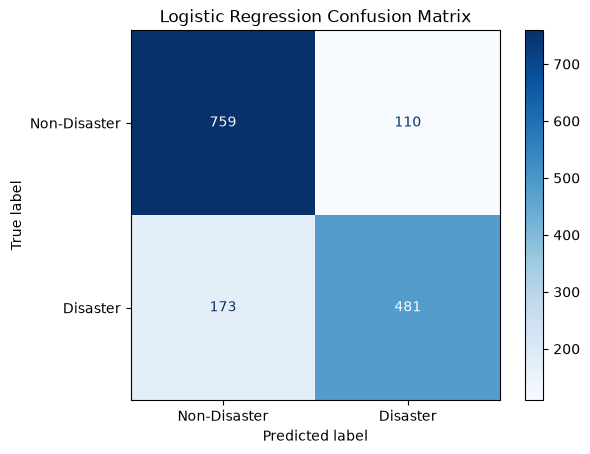

In [19]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Disaster", "Disaster"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [20]:
results = pd.DataFrame({
    "Tweet": X_test.values,
    "Actual": y_test.values,
    "Predicted": lr_pred
})

wrong_predictions = results[
    results["Actual"] != results["Predicted"]
]

print("Number of Wrong Predictions:", len(wrong_predictions))

wrong_predictions.head(10)

Number of Wrong Predictions: 283


,Tweet,Actual,Predicted
0,step one get that mass murderers portrait off ...,0,1
5,hollywood movie about trapped miners released ...,1,0
6,thu aug 06 2015 012032 gmt0000 utc millcityio ...,1,0
7,i cant drown my demons they know how to swim,1,0
13,we need these plants in the pacific during the...,1,0
14,if firefighters acted like cops theyd drive ar...,0,1
19,where did you get that pic from where it shows...,0,1
26,bomb head explosive decisions dat produced mor...,1,0
27,i agree with certain cultural appropriation th...,1,0
29,the dress memes have officially exploded on th...,1,0


In [21]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

SVM


In [ ]:

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM model trained successfully!")

NameError: name 'LinearSVC' is not defined

In [23]:
# Predict on test data

svm_pred = svm_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [24]:
print("===== Linear SVM Performance =====\n")

print("Accuracy :", round(accuracy_score(y_test, svm_pred), 4))
print("Precision:", round(precision_score(y_test, svm_pred), 4))
print("Recall   :", round(recall_score(y_test, svm_pred), 4))
print("F1 Score :", round(f1_score(y_test, svm_pred), 4))

===== Linear SVM Performance =====

Accuracy : 0.7965
Precision: 0.7792
Recall   : 0.7339
F1 Score : 0.7559


In [25]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       869
           1       0.78      0.73      0.76       654

    accuracy                           0.80      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



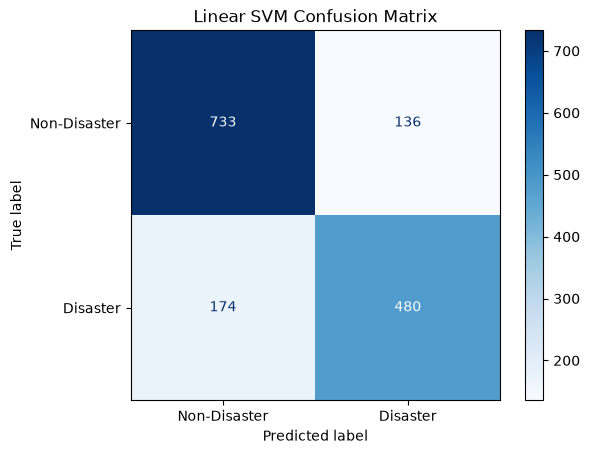

In [26]:
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Disaster", "Disaster"]
)

disp.plot(cmap="Blues")

plt.title("Linear SVM Confusion Matrix")

plt.show()

In [27]:
results = pd.DataFrame({
    "Tweet": X_test.values,
    "Actual": y_test.values,
    "Predicted": svm_pred
})

wrong_predictions = results[
    results["Actual"] != results["Predicted"]
]

print("Number of Wrong Predictions:", len(wrong_predictions))

wrong_predictions.head(10)

Number of Wrong Predictions: 310


,Tweet,Actual,Predicted
0,step one get that mass murderers portrait off ...,0,1
5,hollywood movie about trapped miners released ...,1,0
6,thu aug 06 2015 012032 gmt0000 utc millcityio ...,1,0
7,i cant drown my demons they know how to swim,1,0
13,we need these plants in the pacific during the...,1,0
14,if firefighters acted like cops theyd drive ar...,0,1
19,where did you get that pic from where it shows...,0,1
24,maybe we should call israel and tell them were...,0,1
26,bomb head explosive decisions dat produced mor...,1,0
27,i agree with certain cultural appropriation th...,1,0


In [28]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall
    ],
    "F1 Score": [
        lr_f1,
        svm_f1
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8142,0.8139,0.7355,0.7727
1,Linear SVM,0.7965,0.7792,0.7339,0.7559


In [30]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Model Based on F1 Score:\n")

print(best_model)

Best Model Based on F1 Score:

Model        Logistic Regression
Accuracy                  0.8142
Precision                 0.8139
Recall                    0.7355
F1 Score                  0.7727
Name: 0, dtype: object


In [31]:
lr_pred = lr_model.predict(X_test_tfidf)

TF-IDF + Logistic Regression Evaluation


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("===== TF-IDF + Logistic Regression =====\n")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

===== TF-IDF + Logistic Regression =====

Accuracy : 0.814182534471438
Precision: 0.8138747884940778
Recall   : 0.735474006116208
F1 Score : 0.7726907630522089

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       869
           1       0.81      0.74      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.81      1523
weighted avg       0.81      0.81      0.81      1523



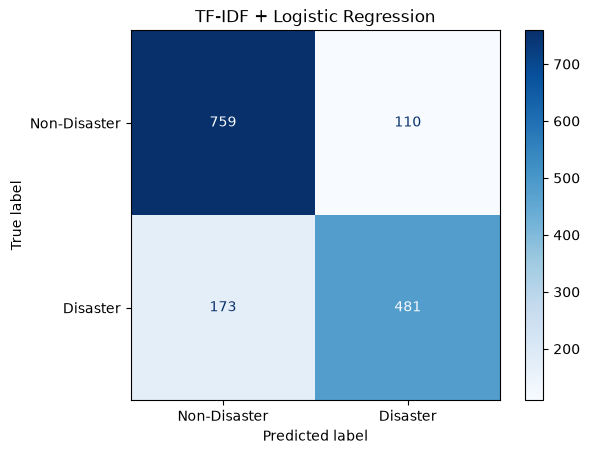

In [33]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Disaster", "Disaster"]
)

disp.plot(cmap="Blues")
plt.title("TF-IDF + Logistic Regression")
plt.show()

TF-IDF + Linear SVM Evaluation

In [34]:
svm_pred = svm_model.predict(X_test_tfidf)

In [35]:
print("===== TF-IDF + Linear SVM =====\n")

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

===== TF-IDF + Linear SVM =====

Accuracy : 0.7964543663821405
Precision: 0.7792207792207793
Recall   : 0.7339449541284404
F1 Score : 0.7559055118110236

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       869
           1       0.78      0.73      0.76       654

    accuracy                           0.80      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



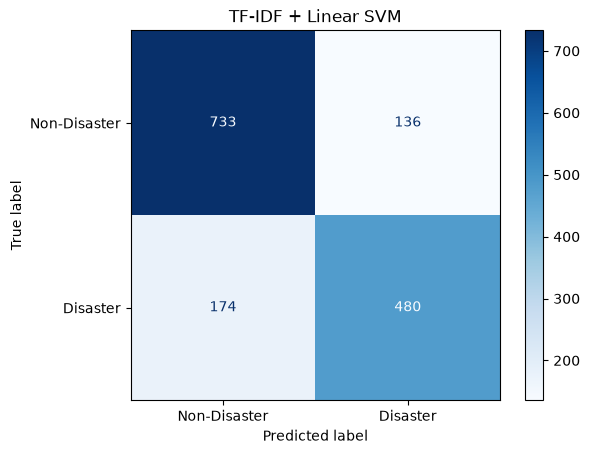

In [36]:
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Disaster", "Disaster"]
)

disp.plot(cmap="Blues")
plt.title("TF-IDF + Linear SVM")
plt.show()

Comparison Table

In [37]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "TF-IDF + Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.8142,0.8139,0.7355,0.7727
1,TF-IDF + Linear SVM,0.7965,0.7792,0.7339,0.7559


In [39]:
best_model = comparison.loc[comparison["F1 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model        TF-IDF + Logistic Regression
Accuracy                           0.8142
Precision                          0.8139
Recall                             0.7355
F1 Score                           0.7727
Name: 0, dtype: object


In [40]:
X_full = train_df["clean_text"]
y_full = train_df["target"]

X_full_tfidf = tfidf.fit_transform(X_full)

final_model = LogisticRegression(
    C=3,
    max_iter=2000,
    solver="liblinear"
)

final_model.fit(X_full_tfidf, y_full)

print("Final model trained successfully!")

Final model trained successfully!


In [41]:
X_test_final = tfidf.transform(test_df["clean_text"])

test_predictions = final_model.predict(X_test_final)

In [42]:
submission = pd.read_csv("../data/sample_submission.csv")

submission["target"] = test_predictions

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [16]:
import pandas as pd

train_df = pd.read_csv("../data/train.csv")

print(train_df.head())

   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [17]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        C=3,
        max_iter=2000,
        solver="liblinear"
    ))
])

cv_scores = cross_val_score(
    pipeline,
    train_df["clean_text"],
    train_df["target"],
    cv=5,
    scoring="f1"
)

print("F1 Score for each fold:", cv_scores)
print("Average CV F1:", cv_scores.mean())

F1 Score for each fold: [0.57611668 0.5297383  0.60047281 0.55021834 0.69369369]
Average CV F1: 0.5900479664675229
